# **Perceptron and Gradient Descent **
# MODULE WITH SOLUTIONS

**what is exactly Gradient Descent?**
As for the example ,it is defined as the Loss function..which is known as the lowet point of the set of model parameters.

**Algorithm:**

1.   Start with a random initialization of the solution (random model parameters).
Calculate the gradient of the loss function. The gradient is a vector that points in the direction of the steepest ascent (uphill).
Incrementally change the solution by moving in the direction of the negative gradient (downhill).
Repeat the previous steps until the loss stops decreasing, which means we have reached a minimum.

The key equation for updating the model's weights is:

        wk+1←wk−η∇J

wk+1  are the new, updated weights for our model.
wk  are the current weights.
η  (eta) is the learning rate. This is a small number that controls how big of a step we take in the downhill direction.
∇J  (nabla J) is the gradient of the loss function  J . It tells us the direction of the steepest ascent. By subtracting it, we move in the opposite direction (downhill).






In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)

We need a problem to solve inorder to test the solution
We will actually work on the
equation:
y=ax2+bx+c

In [2]:
def eval_2nd_degree(coeffs,x):
  a=coeffs[0]*(x*x);
  b=coeffs[1]
  c=coeffs[2];
  y=a+b+c
  return y

hundred_xs = np.random.uniform(-10, 10, 100)
coeffs = [1, 0, 0]

xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_degree(coeffs, x)
    xs.append(x)
    ys.append(y)


In [38]:
# import numpy as np

# def eval_2nd_degree(coeffs, x):
#     a = coeffs[0] * (x * x)
#     b = coeffs[1] * x
#     c = coeffs[2]

#     y = a + b + c
#     return y

# hundred_xs = np.random.uniform(-10, 10, 100)

# # y = 2x² - 3x + 5
# coeffs = [2, -3, 5]

# xs = []
# ys = []

# for x in hundred_xs:
#     y = eval_2nd_degree(coeffs, x)
#     xs.append(x)
#     ys.append(y)

This function above creates a 100 random values to actually give you the uniform distributed values

Text(0, 0.5, 'y')

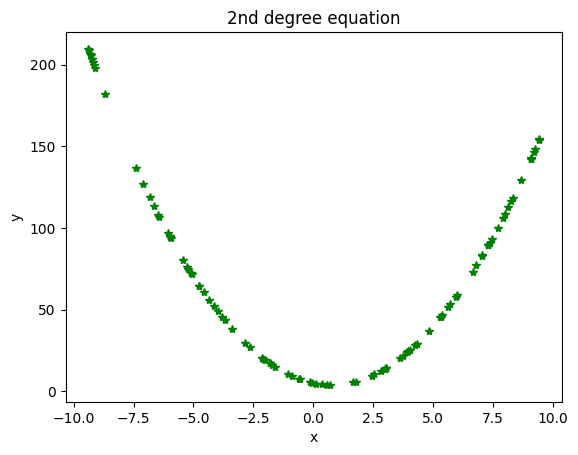

In [39]:
plt.plot(xs,ys,'g*')
plt.title('2nd degree equation')
plt.xlabel('x')
plt.ylabel('y')

In [40]:
def eval_2nd_noisy(coeffs,x,j):
  #provides the function return to noisy output of evaluating a 2nd degree ,specific value
    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c

    interval = [y - j, y + j]
    interval_min = interval[0]
    interval_max = interval[1]
    jit_val = random.random() * interval_max      # Generate a random number in range 0 to interval max

    while interval_min > jit_val:                 # While the random jitter value is less than the interval min,
        jit_val = random.random() * interval_max  # it is not in the right range. Re-roll the generator until it
                                                  # give a number greater than the interval min.

    return jit_val

xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_noisy(coeffs, x, 0.1)
    xs.append(x)
    ys.append(y)


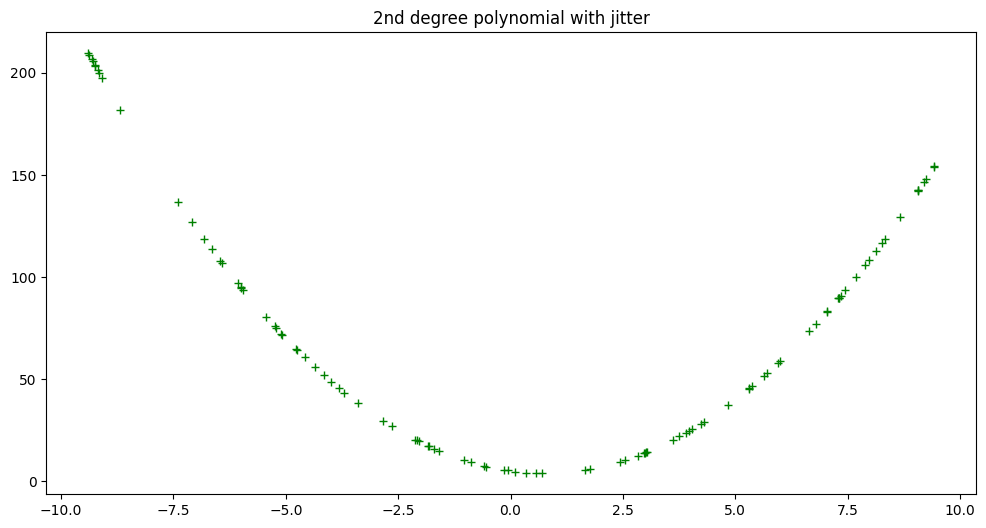

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+')
plt.title('2nd degree polynomial with jitter')
plt.show()

## LOSS FUNCTION
Mean Squared Error->this is done using a loss function,most common loss function is MSE

The MSE is calculated as the average of the squared differences between the true y values ( yi ) and our model's predicted y values ( yi¯ ):

E=1n∑i=1n(yi−yi¯)2

In [42]:
def loss_mse(ys, y_bar):
    """
    Calculates MSE loss.

    Args:
        ys: training data labels
        y_bar: prediction labels

    Returns: Calculated MSE loss.
    """

    return sum((ys - y_bar) * (ys - y_bar)) / len(ys)

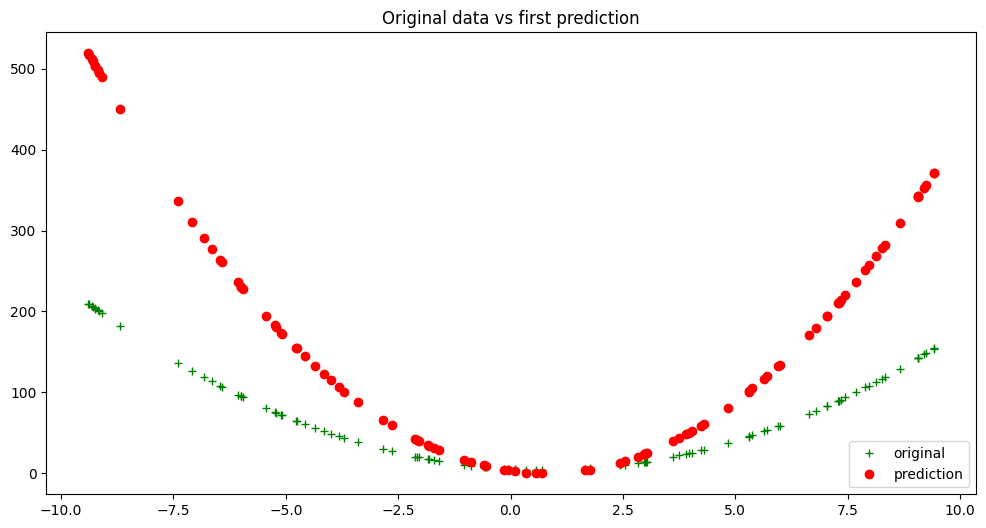

In [43]:
# Pick random coefficients for our initial model
rand_coeffs = (random.randrange(-10, 10), random.randrange(-10, 10), random.randrange(-10, 10))

# Get the model's predictions
y_bar = eval_2nd_degree(rand_coeffs, hundred_xs)

# Plot the original data vs. our random model's prediction
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, y_bar, 'ro', label = 'prediction')
plt.title('Original data vs first prediction')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#WITH A 2x&2 -3x+5

Calculating the MSE

In [44]:
initial_model_loss = loss_mse(ys, y_bar)
initial_model_loss

np.float64(18777.547072236008)

We wish to improve our model. Therefore we want to alter its coefficients  a ,  b  and  c  to decrease the error. Therefore we require knowledge about how each coefficient affects the error. This is achieved by calculating the partial derivative of the loss function with respect to each of the individual coefficients.

After deriving it with the calculus
∂E∂a=−2n∑(yi−yi¯)⋅x2i

Similarly, for b and c:

∂E∂b=−2n∑(yi−yi¯)⋅xi

∂E∂c=−2n∑(yi−yi¯)

In [45]:
def calc_gradient_2nd_poly(rand_coeffs, hundred_xs, ys):
    """
    calculates the gradient for a second degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """

    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(rand_coeffs, hundred_xs)

    for x, y, y_bar in list(zip(hundred_xs, ys, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    num = [i for i in y_bars]
    n = len(num)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)

    return (gradient_a, gradient_b, gradient_c)   # return calculated gradients as a a tuple of its 3 parts

formula for the gradient descent:
new_coeff = old_coeff - learning_rate * gradient

In [46]:
# Calculate the gradients for our random model
calc_grad = calc_gradient_2nd_poly(rand_coeffs, hundred_xs, ys)

# Define a learning rate
lr = 0.001

# Update the coefficients
a_new = rand_coeffs[0] - lr * calc_grad[0]
b_new = rand_coeffs[1] - lr * calc_grad[1]
c_new = rand_coeffs[2] - lr * calc_grad[2]
new_model_coeffs = (a_new, b_new, c_new)

print(f"New model coeffs: {new_model_coeffs}")

# Get predictions with the new coefficients
new_y_bar = eval_2nd_degree(new_model_coeffs, hundred_xs)
updated_model_loss = loss_mse(ys, new_y_bar)

print(f"Now have smaller model loss: {updated_model_loss} vs {initial_model_loss}")

New model coeffs: (np.float64(-7.309940017046134), np.float64(-7.792655698141651), np.float64(2.795513338050919))
Now have smaller model loss: 187957.55941140815 vs 18777.547072236008


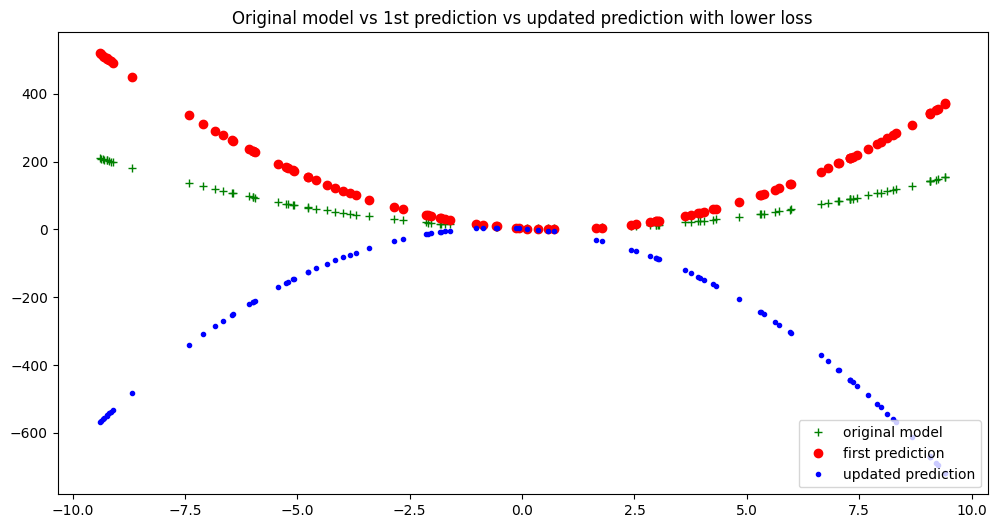

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original model')
plt.plot(xs, y_bar, 'ro', label = 'first prediction')
plt.plot(xs, new_y_bar, 'b.', label = 'updated prediction')
plt.title('Original model vs 1st prediction vs updated prediction with lower loss')
plt.legend(loc="lower right")
plt.show()

In [49]:
# import numpy as np
# #
# # True polynomial
# def eval_2nd_degree(coeffs, x):
#     a, b, c = coeffs
#     return a*x**2 + b*x + c

# # Mean Squared Error Loss
# def loss_mse(y_true, y_pred):
#     return np.mean((y_true - y_pred)**2)

# # Gradient calculation
# def calc_gradient_2nd_poly(coeffs, xs, ys):
#     a, b, c = coeffs

#     y_pred = eval_2nd_degree(coeffs, xs)

#     error = y_pred - ys
#     n = len(xs)

#     da = (2/n) * np.sum(error * xs**2)
#     db = (2/n) * np.sum(error * xs)
#     dc = (2/n) * np.sum(error)

#     return np.array([da, db, dc])

# # -----------------------------
# # Generate training data
# # -----------------------------

# true_coeffs = [2, -3, 5]

# xs = np.random.uniform(-10, 10, 100)

# ys = eval_2nd_degree(true_coeffs, xs)

# # Random starting coefficients
# rand_coeffs = np.array([1.0, 1.0, 1.0])

# print("Initial coeffs:", rand_coeffs)

# # Initial prediction
# y_pred = eval_2nd_degree(rand_coeffs, xs)

# initial_loss = loss_mse(ys, y_pred)

# print("Initial Loss:", initial_loss)

# # -----------------------------
# # Gradient Descent
# # -----------------------------

# lr = 0.0001

# for i in range(1000):

#     grad = calc_gradient_2nd_poly(rand_coeffs, xs, ys)

#     rand_coeffs = rand_coeffs - lr * grad

# # Final prediction
# new_pred = eval_2nd_degree(rand_coeffs, xs)

# final_loss = loss_mse(ys, new_pred)

# print("Final coeffs:", rand_coeffs)
# print("Final Loss:", final_loss)

Initial coeffs: [1. 1. 1.]
Initial Loss: 3247.808917024917
Final coeffs: [ 2.05671491 -3.01217436  1.34320364]
Final Loss: 5.462784728372872


Doing number of iterations based on the for better epochs

In [25]:
def calc_gradient_2nd_poly_for_GD(coeffs, inputs_x, outputs_y, lr):
    """
    calculates the gradient for a second degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points
        lr: learning rate

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """
    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(coeffs, inputs_x)

    for x,y,y_bar in list(zip(inputs_x, outputs_y, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    num = [i for i in y_bars]
    n = len(num)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)


    a_new = coeffs[0] - lr * gradient_a
    b_new = coeffs[1] - lr * gradient_b
    c_new = coeffs[2] - lr * gradient_c

    new_model_coeffs = (a_new, b_new, c_new)

    # update with these new coeffs:
    new_y_bar = eval_2nd_degree(new_model_coeffs, inputs_x)

    updated_model_loss = loss_mse(outputs_y, new_y_bar)
    return updated_model_loss, new_model_coeffs, new_y_bar

In [59]:
def calc_gradient_2nd_poly_for_GD(coeffs, inputs_x, outputs_y, lr):
    """
    calculates the gradient for a second degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points
        lr: learning rate

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """
    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(coeffs, inputs_x)

    for x,y,y_bar in list(zip(inputs_x, outputs_y, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    num = [i for i in y_bars]
    n = len(num)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)


    a_new = coeffs[0] -lr * gradient_a
    b_new = coeffs[1] -lr * gradient_b
    c_new = coeffs[2] - lr * gradient_c

    new_model_coeffs = (a_new, b_new, c_new)

    # update with these new coeffs:
    new_y_bar = eval_2nd_degree(new_model_coeffs, inputs_x)

    updated_model_loss = loss_mse(outputs_y, new_y_bar)
    return updated_model_loss, new_model_coeffs, new_y_bar

In [52]:
def gradient_descent(epochs, lr):
    """
    Perform gradient descent for a second degree polynomial.

    Args:
        epochs: number of iterations to perform of finding new coefficients and updatingt loss.
        lr: specified learning rate

    Returns: Tuple containing (updated_model_loss, new_model_coeffs, new_y_bar predictions, saved loss updates)

    """
    losses = []
    rand_coeffs_to_test = rand_coeffs
    for i in range(epochs):
        loss = calc_gradient_2nd_poly_for_GD(rand_coeffs_to_test, hundred_xs, ys, lr)
        rand_coeffs_to_test = loss[1]
        losses.append(loss[0])
    print(losses)
    return loss[0], loss[1], loss[2], losses  # (updated_model_loss, new_model_coeffs, new_y_bar, saved loss updates)

In [29]:
GD = gradient_descent(30000, 0.0003)

[np.float64(10588.442758671343), np.float64(834.5515696036916), np.float64(68.89765418415817), np.float64(8.814371626980842), np.float64(4.0918251360139735), np.float64(3.7203201024633348), np.float64(3.688736357661244), np.float64(3.6842824122796793), np.float64(3.681833741381501), np.float64(3.6795788136104504), np.float64(3.677330478847667), np.float64(3.6750866392628403), np.float64(3.672843602540666), np.float64(3.6706020659926684), np.float64(3.6683618069677446), np.float64(3.6661228847732783), np.float64(3.663885281652345), np.float64(3.661649001582617), np.float64(3.6594140424665955), np.float64(3.6571804039098224), np.float64(3.654948085041493), np.float64(3.652717085124782), np.float64(3.6504874033858825), np.float64(3.6482590390619443), np.float64(3.6460319913875985), np.float64(3.643806259598728), np.float64(3.641581842931463), np.float64(3.6393587406224), np.float64(3.6371369519085834), np.float64(3.6349164760274832), np.float64(3.6326973122170028), np.float64(3.6304794597

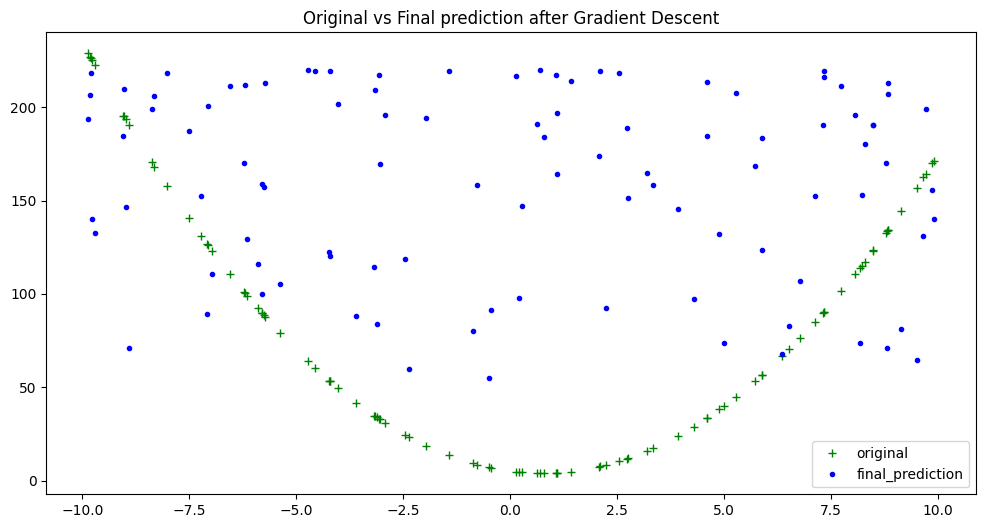

In [53]:
plt.figure(figsize=(12,6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, GD[2], 'b.', label = 'final_prediction')
plt.title('Original vs Final prediction after Gradient Descent')
plt.legend(loc = "lower right")
plt.show()

In [31]:
print(f"Final Coefficients predicted: {GD[1]}")
print(f"Original Coefficients: {coeffs}")

Final Coefficients predicted: (np.float64(1.0034326059659293), np.float64(5.871903238189133), np.float64(-6.090882845057016))
Original Coefficients: [1, 0, 0]


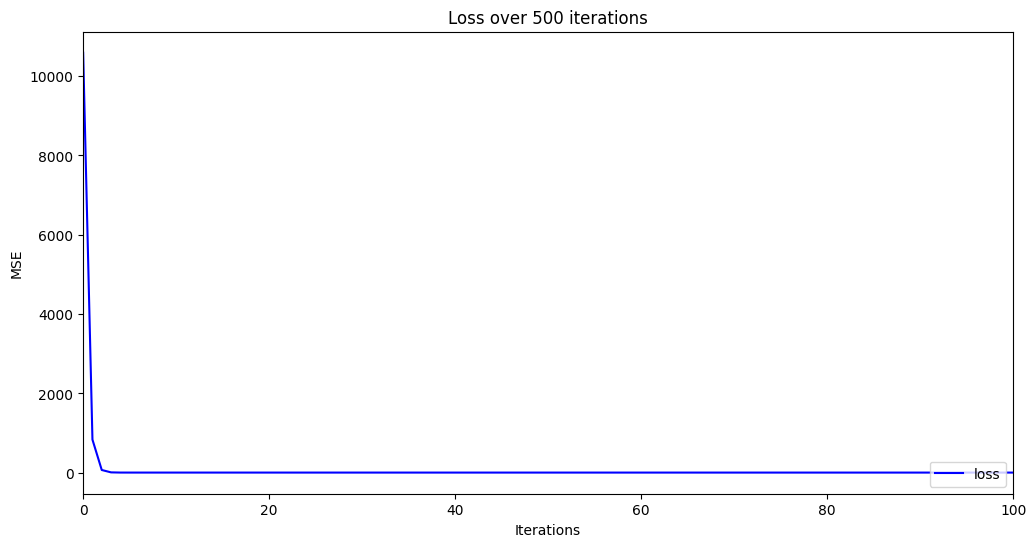

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(GD[3], 'b-', label = 'loss')
# plt.xlim(0,50)
plt.title('Loss over 500 iterations')
plt.legend(loc="lower right")
plt.xlim((0,100))
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.show()

## MINI BATCH GD
In Mini-Batch GD, we shuffle the dataset and then divide it into small batches (e.g., 32 samples per batch). We then calculate the gradient and update the weights based on each mini-batch, one by one. One pass through all the mini-batches is called one epoch.

Pros:

It's much faster than Batch GD.
It introduces some noise into the gradient estimates, which can sometimes help the model escape from poor local minima.
Cons: The convergence is not as smooth as with Batch GD; the loss can fluctuate.

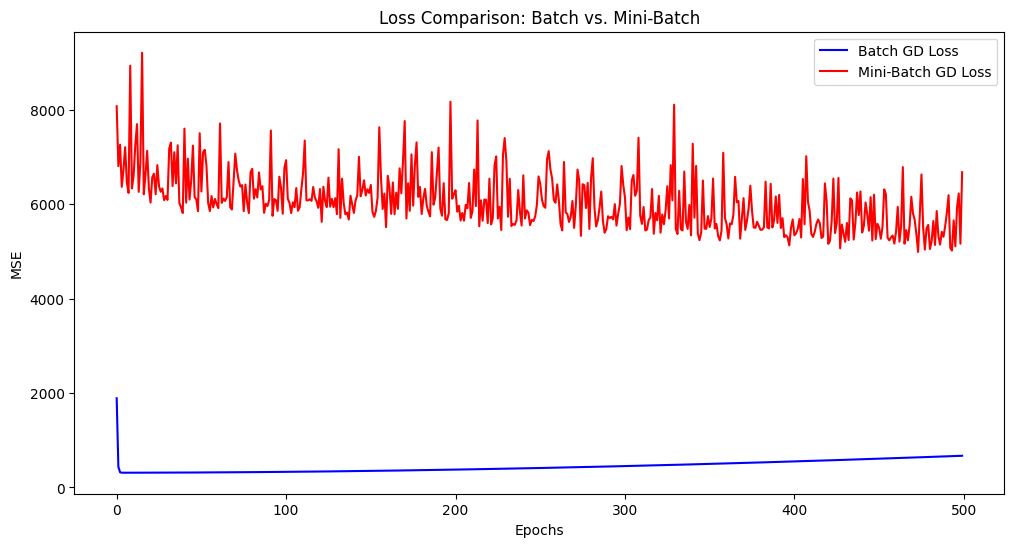

In [50]:
def mini_batch_gradient_descent(epochs, lr, batch_size):
    """
    Perform mini-batch gradient descent.

    Args:
        epochs: number of iterations to perform.
        lr: specified learning rate
        batch_size: number of samples per mini-batch

    Returns: Tuple containing (final loss, final coefficients, list of losses per batch)
    """
    losses = []
    # Start with our initial random coefficients
    coeffs_to_test = rand_coeffs

    # Convert data to numpy arrays for easier slicing
    X_data = np.array(hundred_xs)
    Y_data = np.array(ys)

    for i in range(epochs):
        # Shuffle data at the beginning of each epoch
        # This is crucial for mini-batch GD to work well!
        p = np.random.permutation(len(X_data))
        X_data, Y_data = X_data[p], Y_data[p]

        epoch_loss = []
        # Iterate over mini-batches
        for j in range(0, len(X_data), batch_size):
            # Get the current mini-batch
            X_batch = X_data[j:j+batch_size]
            Y_batch = Y_data[j:j+batch_size]

            # Calculate gradient and update on the mini-batch
            loss, new_coeffs, _ = calc_gradient_2nd_poly_for_GD(coeffs_to_test, X_batch, Y_batch, lr)
            coeffs_to_test = new_coeffs
            epoch_loss.append(loss)

        # Average loss for the epoch
        losses.append(np.mean(epoch_loss))

    # Return the final results after all epochs
    final_y_bar = eval_2nd_degree(coeffs_to_test, hundred_xs)
    final_loss = loss_mse(ys, final_y_bar)

    return final_loss, coeffs_to_test, losses

# Run Mini-Batch GD
# Note: We can often use fewer epochs and a slightly larger learning rate
MGD = mini_batch_gradient_descent(epochs=500, lr=0.0001, batch_size=16)

# Plotting the loss curves for comparison
plt.figure(figsize=(12, 6))
# We only plot the first 500 losses from Batch GD for a fair comparison
plt.plot(GD[3][:500], 'b-', label = 'Batch GD Loss')
plt.plot(MGD[2], 'r-', label = 'Mini-Batch GD Loss')
plt.title('Loss Comparison: Batch vs. Mini-Batch')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

# SOLUTIONS

1.The polynomial was changed from (y = x^2) to (y = 2x^2 - 3x + 5) by updating the coefficient array from `[1, 0, 0]` to `[2, -3, 5]`. Here, `2` represents the coefficient of (x^2), `-3` represents the coefficient of (x), and `5` is the constant term. After generating the dataset using the new polynomial, gradient descent was applied to learn the coefficients. The model gradually adjusted its parameters to minimize the mean squared error loss and converged toward the true coefficients ([2, -3, 5]), demonstrating that gradient descent can successfully learn the parameters of a quadratic function from data.


2.Gradient descent is highly affected by the learning rate. When a small learning rate such as 0.0001 is used, the model converges slowly because the parameter updates are very small. A moderate learning rate such as 0.001 usually provides stable and faster convergence. Increasing the learning rate reduces the number of iterations required up to a certain point.

In [54]:
# #3.import numpy as np

# # y = (x-1)(x-2)(x-3)(x-4)(x-5)
# def eval_5th_degree(coeffs, x):
#     return (coeffs[0]*x**5 +
#             coeffs[1]*x**4 +
#             coeffs[2]*x**3 +
#             coeffs[3]*x**2 +
#             coeffs[4]*x +
#             coeffs[5])

# xs = np.random.uniform(-10,10,100)

# # true polynomial
# true_coeffs = [1,-15,85,-225,274,-120]
# ys = eval_5th_degree(true_coeffs, xs)

# # Different initializations
# init1 = np.array([0,0,0,0,0,0])
# init2 = np.array([10,10,10,10,10,10])
# init3 = np.array([-10,-10,-10,-10,-10,-10])

# print(init1)
# print(init2)
# print(init3)

[0 0 0 0 0 0]
[10 10 10 10 10 10]
[-10 -10 -10 -10 -10 -10]


For a fifth-degree polynomial, different initializations can lead to different optimization paths and convergence speeds. The loss surface becomes more complex as the degree increases, making optimization harder. In some cases, different initializations may converge to slightly different solutions or require significantly different numbers of iterations.

For the simpler quadratic function y = x², initialization has much less impact because the loss function is convex and contains a single global minimum. Gradient descent therefore converges to the same solution from almost any reasonable starting point. Different initializations mainly affect the convergence speed rather than the final result.


4.To find a maximum instead of a minimum, the update rule is modified so that the parameters move in the same direction as the gradient. This process is called Gradient Ascent. The update equation becomes θ = θ + α∇J(θ). Gradient ascent increases the objective function value at each step and can be used to locate maxima. When applied to y = x², the algorithm does not converge because the function has no maximum value and increases indefinitely as x moves away from zero.


/tmp/ipykernel_2286/450595442.py:10: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred)**2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


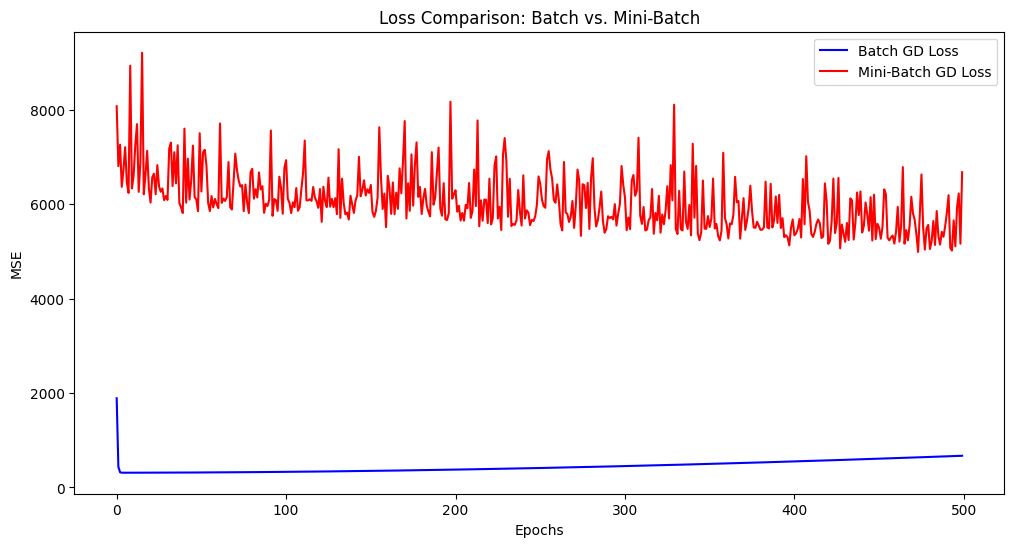

In [60]:
def mini_batch_gradient_descent(epochs, lr, batch_size):
    """
    Perform mini-batch gradient descent.

    Args:
        epochs: number of iterations to perform.
        lr: specified learning rate
        batch_size: number of samples per mini-batch

    Returns: Tuple containing (final loss, final coefficients, list of losses per batch)
    """
    losses = []
    # Start with our initial random coefficients
    coeffs_to_test = rand_coeffs

    # Convert data to numpy arrays for easier slicing
    X_data = np.array(hundred_xs)
    Y_data = np.array(ys)

    for i in range(epochs):
        # Shuffle data at the beginning of each epoch
        # This is crucial for mini-batch GD to work well!
        p = np.random.permutation(len(X_data))
        X_data, Y_data = X_data[p], Y_data[p]

        epoch_loss = []
        # Iterate over mini-batches
        for j in range(0, len(X_data), batch_size):
            # Get the current mini-batch
            X_batch = X_data[j:j+batch_size]
            Y_batch = Y_data[j:j+batch_size]

            # Calculate gradient and update on the mini-batch
            loss, new_coeffs, _ = calc_gradient_2nd_poly_for_GD(coeffs_to_test, X_batch, Y_batch, lr)
            coeffs_to_test = new_coeffs
            epoch_loss.append(loss)

        # Average loss for the epoch
        losses.append(np.mean(epoch_loss))

    # Return the final results after all epochs
    final_y_bar = eval_2nd_degree(coeffs_to_test, hundred_xs)
    final_loss = loss_mse(ys, final_y_bar)

    return final_loss, coeffs_to_test, losses

# Run Mini-Batch GD
# Note: We can often use fewer epochs and a slightly larger learning rate
# MGD = mini_batch_gradient_descent(epochs=500, lr=0.0001, batch_size=16)
MGD1 = mini_batch_gradient_descent(
    epochs=500,
    lr=0.0001,
    batch_size=1
)#SGD
# Plotting the loss curves for comparison
plt.figure(figsize=(12, 6))
# We only plot the first 500 losses from Batch GD for a fair comparison
plt.plot(GD[3][:500], 'b-', label = 'Batch GD Loss')
plt.plot(MGD[2], 'r-', label = 'Mini-Batch GD Loss')
plt.title('Loss Comparison: Batch vs. Mini-Batch')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

/tmp/ipykernel_2286/450595442.py:10: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred)**2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


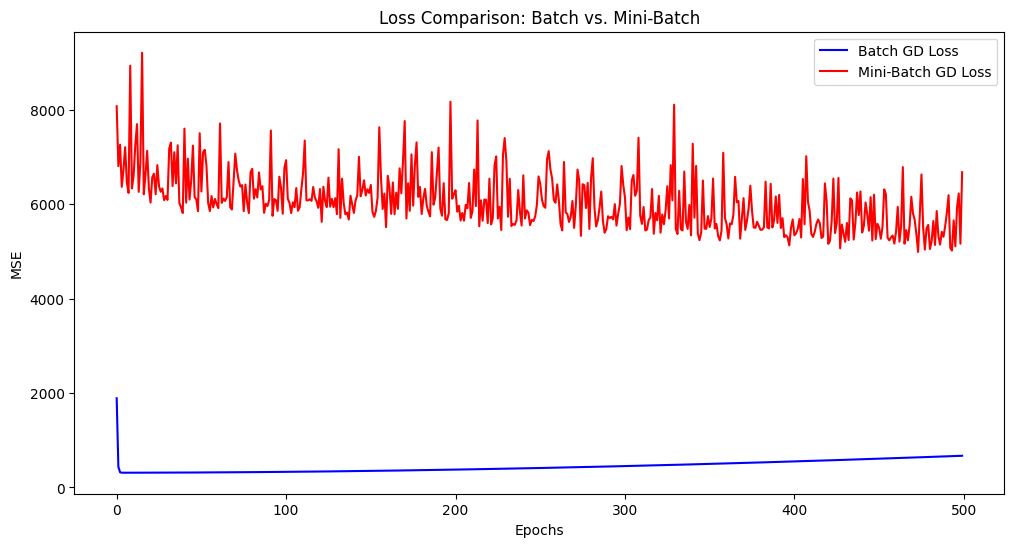

In [61]:
def mini_batch_gradient_descent(epochs, lr, batch_size):
    """
    Perform mini-batch gradient descent.

    Args:
        epochs: number of iterations to perform.
        lr: specified learning rate
        batch_size: number of samples per mini-batch

    Returns: Tuple containing (final loss, final coefficients, list of losses per batch)
    """
    losses = []
    # Start with our initial random coefficients
    coeffs_to_test = rand_coeffs

    # Convert data to numpy arrays for easier slicing
    X_data = np.array(hundred_xs)
    Y_data = np.array(ys)

    for i in range(epochs):
        # Shuffle data at the beginning of each epoch
        # This is crucial for mini-batch GD to work well!
        p = np.random.permutation(len(X_data))
        X_data, Y_data = X_data[p], Y_data[p]

        epoch_loss = []
        # Iterate over mini-batches
        for j in range(0, len(X_data), batch_size):
            # Get the current mini-batch
            X_batch = X_data[j:j+batch_size]
            Y_batch = Y_data[j:j+batch_size]

            # Calculate gradient and update on the mini-batch
            loss, new_coeffs, _ = calc_gradient_2nd_poly_for_GD(coeffs_to_test, X_batch, Y_batch, lr)
            coeffs_to_test = new_coeffs
            epoch_loss.append(loss)

        # Average loss for the epoch
        losses.append(np.mean(epoch_loss))

    # Return the final results after all epochs
    final_y_bar = eval_2nd_degree(coeffs_to_test, hundred_xs)
    final_loss = loss_mse(ys, final_y_bar)

    return final_loss, coeffs_to_test, losses

# Run Mini-Batch GD
# Note: We can often use fewer epochs and a slightly larger learning rate
# MGD = mini_batch_gradient_descent(epochs=500, lr=0.0001, batch_size=16)
MGD3 = mini_batch_gradient_descent(
    epochs=500,
    lr=0.0001,
    batch_size=100
)#MGD3
# Plotting the loss curves for comparison
plt.figure(figsize=(12, 6))
# We only plot the first 500 losses from Batch GD for a fair comparison
plt.plot(GD[3][:500], 'b-', label = 'Batch GD Loss')
plt.plot(MGD[2], 'r-', label = 'Mini-Batch GD Loss')
plt.title('Loss Comparison: Batch vs. Mini-Batch')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

The batch size determines the number of samples used to compute each gradient update. When batch_size = 1, the algorithm becomes Stochastic Gradient Descent (SGD). Updates occur after every sample, producing noisy but frequent parameter updates. When batch_size = 100, which equals the entire dataset size, the algorithm becomes Batch Gradient Descent. The gradient estimate becomes very stable but updates occur less frequently. Mini-batch gradient descent, using intermediate batch sizes such as 16 or 32, provides a balance between computational efficiency and convergence stability.


In [62]:
velocity = np.zeros(3)

beta = 0.9
lr = 0.0001

coeffs = np.array(rand_coeffs)

losses = []

for i in range(500):

    grad = calc_gradient_2nd_poly(
        coeffs,
        hundred_xs,
        ys
    )

    velocity = beta * velocity + (1-beta) * grad

    coeffs = coeffs - lr * velocity

    pred = eval_2nd_degree(coeffs, hundred_xs)

    losses.append(loss_mse(ys, pred))

print(coeffs)

[-1.41664059e+144 -1.68398479e+142 -2.37035084e+142]


/tmp/ipykernel_2286/450595442.py:10: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred)**2)


Gradient Descent with Momentum is an extension of standard gradient descent that incorporates information from previous updates. A velocity term accumulates past gradients and influences future parameter updates. This helps accelerate movement in directions that consistently reduce the loss while damping oscillations in noisy directions. Momentum is especially useful for Mini-Batch Gradient Descent because mini-batch gradients can fluctuate significantly between batches. By smoothing these fluctuations, momentum improves convergence speed and training stability.
